In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Titanic dataset (built into seaborn, same data as Kaggle's Titanic dataset)
df = sns.load_dataset('titanic')

# Clean data
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Features and target
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 75.52%


/tmp/ipykernel_5951/2736724094.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2023-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 188.23


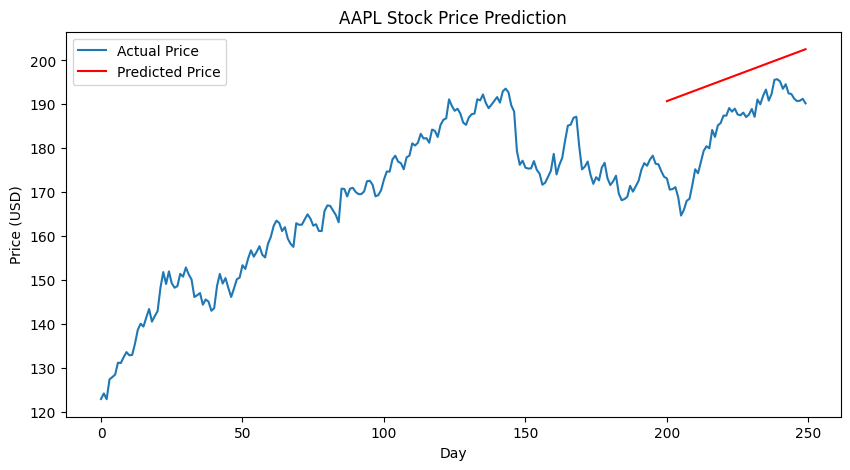

In [ ]:
!pip install yfinance -q
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Download historical stock data (Apple)
data = yf.download('AAPL', start='2023-01-01', end='2024-01-01')
data = data[['Close']].reset_index()
data['Day'] = np.arange(len(data))

# Features and target
X = data[['Day']]
y = data['Close']

# Split (last 20% as test)
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse:.2f}")

# Plot
plt.figure(figsize=(10,5))
plt.plot(data['Day'], data['Close'], label='Actual Price')
plt.plot(X_test['Day'], predictions, label='Predicted Price', color='red')
plt.xlabel('Day')
plt.ylabel('Price (USD)')
plt.title('AAPL Stock Price Prediction')
plt.legend()
plt.show()